In [1]:
import pandas as pd 

In [2]:
df = pd.read_csv('../data/heart_disease.csv')

In [3]:
# Checking the shape 

print(df.shape)

(4238, 16)


In [4]:
import matplotlib.pyplot as plt 


C:\Users\rashd\AppData\Local\Temp\ipykernel_18592\1053007479.py:5: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


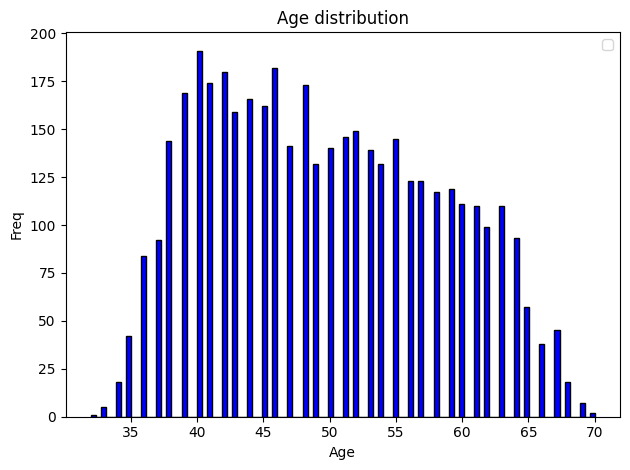

In [5]:
plt.hist(df['age'], bins=100, color = 'blue', edgecolor = 'black')
plt.title("Age distribution")
plt.xlabel("Age")
plt.ylabel("Freq")
plt.legend()
plt.tight_layout()
plt.show()


In [6]:
counts = df[['currentSmoker']].value_counts()


# Defining labels and height 

labels = ['Non-smokers', 'Smokers']
height = [counts[0], counts[1]]



C:\Users\rashd\AppData\Local\Temp\ipykernel_18592\569599576.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


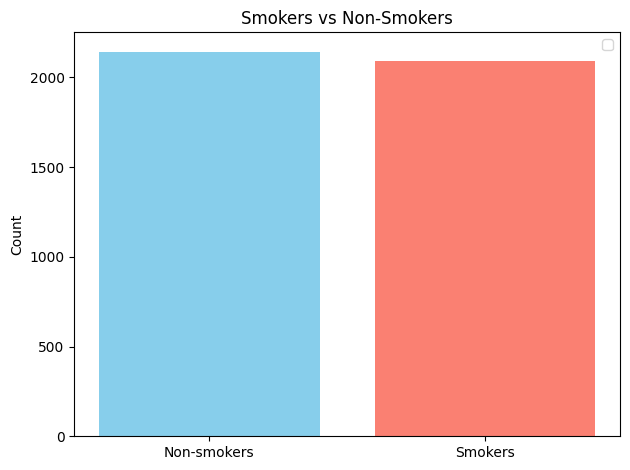

In [7]:
# Bar chart 


plt.bar(labels, height, color= ['skyblue', 'salmon'])

plt.title("Smokers vs Non-Smokers")
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
# Seeing heart_stroke 

stroke_counts = df['Heart_ stroke'].value_counts()
labels = ['No stroke', 'Stroke']

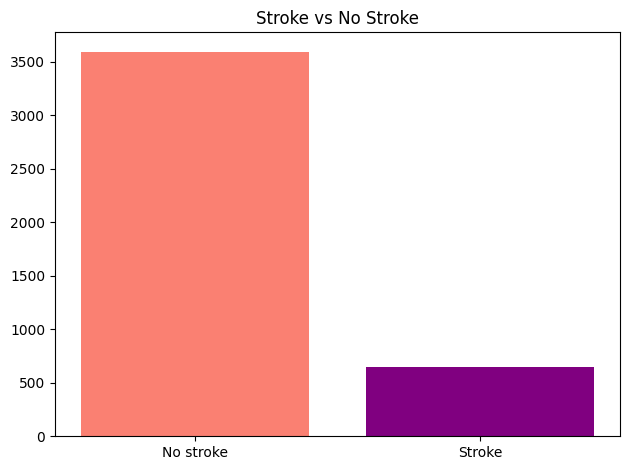

In [9]:
plt.bar(labels, stroke_counts.values, color=['salmon', 'purple'])
plt.title("Stroke vs No Stroke") 
plt.tight_layout()
plt.show()

In [10]:
# finding missing values 


print(df.isnull().sum())

Gender               0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
Heart_ stroke        0
dtype: int64


## Data Cleaning (Preprocessing)

In [11]:
# Droppig column
df.drop(columns= ['education'], inplace= True )

print(df.columns)

Index(['Gender', 'age', 'currentSmoker', 'cigsPerDay', 'BPMeds',
       'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP',
       'diaBP', 'BMI', 'heartRate', 'glucose', 'Heart_ stroke'],
      dtype='object')


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4238 entries, 0 to 4237
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Gender           4238 non-null   object 
 1   age              4238 non-null   int64  
 2   currentSmoker    4238 non-null   int64  
 3   cigsPerDay       4209 non-null   float64
 4   BPMeds           4185 non-null   float64
 5   prevalentStroke  4238 non-null   object 
 6   prevalentHyp     4238 non-null   int64  
 7   diabetes         4238 non-null   int64  
 8   totChol          4188 non-null   float64
 9   sysBP            4238 non-null   float64
 10  diaBP            4238 non-null   float64
 11  BMI              4219 non-null   float64
 12  heartRate        4237 non-null   float64
 13  glucose          3850 non-null   float64
 14  Heart_ stroke    4238 non-null   object 
dtypes: float64(8), int64(4), object(3)
memory usage: 496.8+ KB


In [13]:
cols_to_fix = ['glucose','BMI','heartRate', 'cigsPerDay','totChol','BPMeds' ]


# filling missing values with median 


for col in cols_to_fix:
    if col in df.columns:
        # Filling values 
        median_value = df[col].median()
        df[col] = df[col].fillna(median_value)


print("Holes remaining:")
print(df.isnull().sum())


Holes remaining:
Gender             0
age                0
currentSmoker      0
cigsPerDay         0
BPMeds             0
prevalentStroke    0
prevalentHyp       0
diabetes           0
totChol            0
sysBP              0
diaBP              0
BMI                0
heartRate          0
glucose            0
Heart_ stroke      0
dtype: int64


## Encoding

In [14]:
from sklearn.preprocessing import LabelEncoder

In [15]:
le = LabelEncoder() 
df['Gender'] = le.fit_transform(df['Gender'])
df['prevalentStroke'] = le.fit_transform(df['prevalentStroke'])
df['Heart_ stroke'] = le.fit_transform(df['Heart_ stroke'])

## Feature engineering 

In [16]:
# Heart stress 
df['pulse_pressure'] = df['sysBP'] - df['diaBP']


# Age-Sugar risk 
df['age_glucose_risk'] = df['age'] * df['glucose']
# Health score
df['total_health_risk'] = df['age'] + df['sysBP'] + df['glucose']

# Total BP 
df['total_BP'] = df['sysBP'] + df['diaBP']


# High risk smoker 
df['smoking_age_impact'] = df['age'] * df['cigsPerDay']


# Diabetes-Sugar link 
df['diabetes_glucose_impact'] = df['diabetes'] * df['glucose']



In [18]:
X = df[['age', 'cigsPerDay', 'sysBP', 'diaBP', 'glucose', 'diabetes', 'pulse_pressure', 'age_glucose_risk']]
y = df['Heart_ stroke']

## Scalling


In [19]:
from sklearn.model_selection import train_test_split

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state= 42)


In [21]:
# Scalling 

from sklearn.preprocessing import StandardScaler

In [22]:
Standard_scalar = StandardScaler()

# Learn from data and changing them

X_train_scaled = Standard_scalar.fit_transform(X_train)

X_test_scaled = Standard_scalar.fit_transform(X_test)

## Model training

In [23]:
from sklearn.linear_model import LogisticRegression

In [24]:
model = LogisticRegression(class_weight='balanced',solver='liblinear', C=0.1, max_iter=1000)

model.fit(X_train_scaled, y_train)


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",0.1
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :ter

## Model prediction

In [25]:
# Prediction 
 # y_pred = X_test_scaled
y_pred = model.predict(X_test_scaled)



## Checking model accuracy

In [26]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

print(f"accuracy:{accuracy_score(y_test, y_pred)}")
print(f"\nclassification report:{classification_report(y_test, y_pred)}")
print(f"\nconfusion matrix:{confusion_matrix(y_test, y_pred)}")
print(f"\nprecision:{precision_score(y_test, y_pred)}")
print(f"\nrecall:{recall_score(y_test, y_pred)}")
print(f"\nf1-score:{f1_score(y_test, y_pred)}")

accuracy:0.6485849056603774

classification report:              precision    recall  f1-score   support

           0       0.91      0.65      0.76       724
           1       0.23      0.61      0.34       124

    accuracy                           0.65       848
   macro avg       0.57      0.63      0.55       848
weighted avg       0.81      0.65      0.70       848


confusion matrix:[[474 250]
 [ 48  76]]

precision:0.2331288343558282

recall:0.6129032258064516

f1-score:0.3377777777777778


In [27]:
# Saving the model 
import joblib 



# Save the model 

joblib.dump(model, 'model.pkl')

# Saving the standardScalar
joblib.dump(Standard_scalar, 'scalar.pkl')



print("Successfully saved our model and scalar")

Successfully saved our model and scalar
